In [ ]:
import simpy
import numpy as np
import matplotlib.pyplot as plt

Se disminuyen el tiempo entre los fallos

In [7]:
n = 5  #cantidad de robots
cantidad_reparadores = 2  # cantidad de reparadores
media_fallos = 10  # media de tiempo entre fallos 
media_reparacion = 3  # media de tiempo de reparación 

In [13]:
tiempo_simulacion = 100_000     # Tiempo total de simulación 
np.random.seed(42)        # Semilla para reproducibilidad
robots_operativos = []    # Eventos de cambio en robots operativos
reparadores_ocupados = []       # Eventos de cambio en reparadores ocupados
tiempo_reparacion = []      # Tiempos de reparación 

def proceso(env, reparadores):
    global count
    while True:
        tiempo_fracaso = np.random.exponential(media_fallos)
        yield env.timeout(tiempo_fracaso)
        
        breakdown_time = env.now
        count -= 1 #si ocurre una falla
        robots_operativos.append((env.now, count))
        
        # Solicitar un reparador
        with reparadores.request() as requisito:

            yield requisito
            ocupado = cantidad_reparadores - reparadores.count
            reparadores_ocupados.append((env.now, ocupado))
            
            repair_duration = np.random.exponential(media_reparacion)
            yield env.timeout(repair_duration)
    
        ocupado = cantidad_reparadores - reparadores.count
        reparadores_ocupados.append((env.now, ocupado))
       
        count += 1
        robots_operativos.append((env.now, count))
        tiempo_reparacion.append(env.now - breakdown_time)

env = simpy.Environment()
reparadores = simpy.Resource(env, capacity=cantidad_reparadores)
count = n  
robots_operativos.append((0, count))  

for _ in range(n):
    env.process(proceso(env, reparadores))

# simulacion
env.run(until=tiempo_simulacion)
# numero medio de robots operativos
robots_operativos.sort(key=lambda x: x[0])
total_operational = 0
prev_time, prev_count = robots_operativos[0]

for time, count in robots_operativos[1:]:
    delta = time - prev_time
    total_operational += prev_count * delta
    prev_time, prev_count = time, count

# Agregar tiempo restante 
delta = tiempo_simulacion - prev_time
total_operational += prev_count * delta
avg_operational = total_operational / tiempo_simulacion

# tiempo promedio de reparacion
avg_repair_time = np.mean(tiempo_reparacion) if tiempo_reparacion else 0

# porcentaje de tiempo con al menos un reparador inactivo
reparadores_ocupados.sort(key=lambda x: x[0])
idle_time = 0
prev_time, prev_busy = reparadores_ocupados[0]

for time, busy in reparadores_ocupados[1:]:
    delta = time - prev_time
    if prev_busy < cantidad_reparadores:
        idle_time += delta
    prev_time, prev_busy = time, busy

delta = tiempo_simulacion - prev_time
if prev_busy < cantidad_reparadores:
    idle_time += delta


In [11]:
percentage_idle = (idle_time / tiempo_simulacion) * 100
print(f"Número medio de robots operativos: {avg_operational:.2f}")
print(f"Tiempo promedio de reparación: {avg_repair_time:.2f} horas")
print(f"Porcentaje de tiempo con algún operario inactivo: {percentage_idle:.2f}%")

Número medio de robots operativos: 3.71
Tiempo promedio de reparación: 3.47 horas
Porcentaje de tiempo con algún operario inactivo: 74.33%


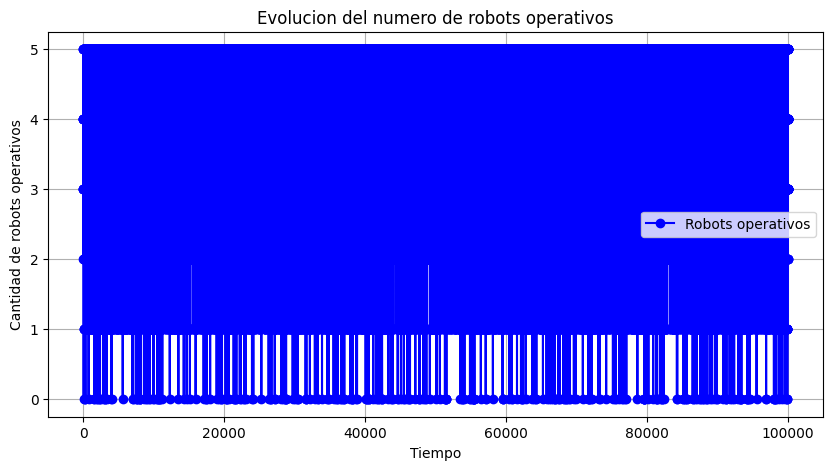

In [9]:
tiempos, robots = zip(*robots_operativos)
plt.figure(figsize=(10, 5))
plt.plot(tiempos, robots, marker='o', linestyle='-', color='b', label="Robots operativos")
plt.xlabel("Tiempo")
plt.ylabel("Cantidad de robots operativos")
plt.title("Evolucion del numero de robots operativos")
plt.legend()
plt.grid(True)
plt.show()


Se disminuye los reparadores

In [ ]:
n = 5  #cantidad de robots
cantidad_reparadores = 1  # cantidad de reparadores
media_fallos = 30  # media de tiempo entre fallos 
media_reparacion = 3  # media de tiempo de reparación 

In [14]:
print(f"Número medio de robots operativos: {avg_operational:.2f}")
print(f"Tiempo promedio de reparación: {avg_repair_time:.2f} horas")
print(f"Porcentaje de tiempo con algún operario inactivo: {percentage_idle:.2f}%")

Número medio de robots operativos: 4.36
Tiempo promedio de reparación: 4.41 horas
Porcentaje de tiempo con algún operario inactivo: 74.33%


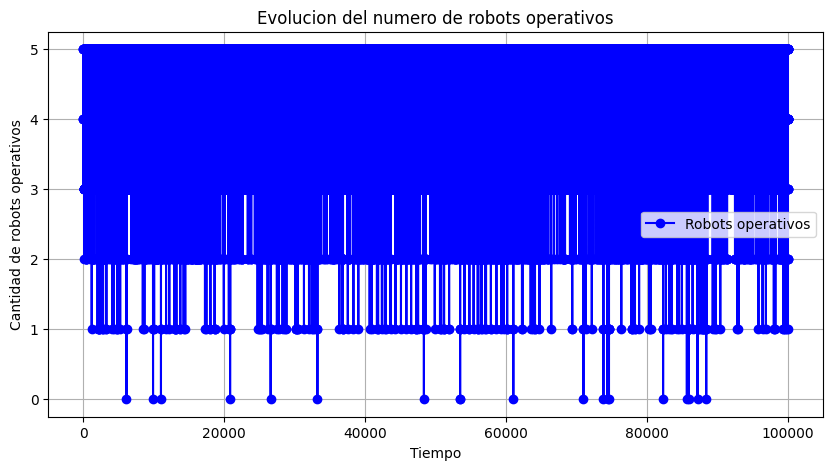

In [15]:
tiempos, robots = zip(*robots_operativos)
plt.figure(figsize=(10, 5))
plt.plot(tiempos, robots, marker='o', linestyle='-', color='b', label="Robots operativos")
plt.xlabel("Tiempo")
plt.ylabel("Cantidad de robots operativos")
plt.title("Evolucion del numero de robots operativos")
plt.legend()
plt.grid(True)
plt.show()

Se disminuye el tiempo entre fallos y se aumenta el tiempo de reparacion

In [16]:
n = 5  #cantidad de robots
cantidad_reparadores = 2  # cantidad de reparadores
media_fallos = 20  # media de tiempo entre fallos 
media_reparacion = 4  # media de tiempo de reparación 

In [17]:
print(f"Número medio de robots operativos: {avg_operational:.2f}")
print(f"Tiempo promedio de reparación: {avg_repair_time:.2f} horas")
print(f"Porcentaje de tiempo con algún operario inactivo: {percentage_idle:.2f}%")

Número medio de robots operativos: 4.36
Tiempo promedio de reparación: 4.41 horas
Porcentaje de tiempo con algún operario inactivo: 74.33%


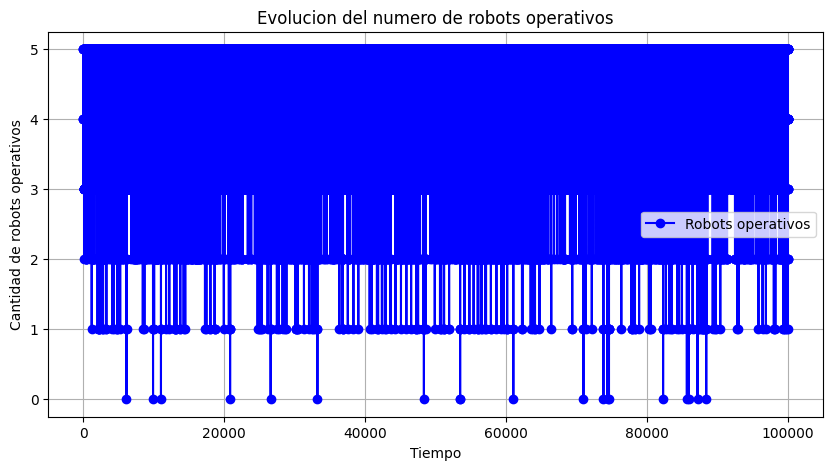

In [18]:
tiempos, robots = zip(*robots_operativos)
plt.figure(figsize=(10, 5))
plt.plot(tiempos, robots, marker='o', linestyle='-', color='b', label="Robots operativos")
plt.xlabel("Tiempo")
plt.ylabel("Cantidad de robots operativos")
plt.title("Evolucion del numero de robots operativos")
plt.legend()
plt.grid(True)
plt.show()